In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import rfpimp as rfp

from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# import custom functions
from src.analysis import *

from pathlib import Path
root = Path.cwd()

In [2]:
CITY = 'nyc'
BANDS_FILE = 'hls_bands2.nc'
INDICES_FILE = 'hls_indices2.nc'



if CITY == 'nyc':
    mn_df = make_nyc_dataframes(root=root, borough='manhattan', all_vars=True)
    print('manhattan df complete')

    bk_df = make_nyc_dataframes(root=root, borough='brooklyn', all_vars=True)
    print('bk df complete')
    
    si_df = make_nyc_dataframes(root=root, borough='staten_island', all_vars=True)
    print('si df complete')
    
    bx_df = make_nyc_dataframes(root=root, borough='bronx', all_vars=True)
    print('bx df complete')
    df = pd.concat([mn_df,bk_df,si_df,bx_df],axis=0)
    del(mn_df,bk_df,si_df,bx_df)
    
else:
    xds1 = xr.open_dataarray(root / 'data' / f'{CITY}_{BANDS_FILE}')
    xds2 = xr.open_dataarray(root / 'data' / f'{CITY}_{INDICES_FILE}') # shared annual and monthly indices
    xds = xr.concat([xds1,xds2],dim='band')

    df = make_dataframe(xds)

(36714, 271)
manhattan df complete
(101002, 271)
bk df complete
(103655, 271)
si df complete
(106917, 271)
bx df complete


In [3]:
vars = get_threshold_variables(df,t=.3,root=root, city=CITY)

In [4]:
vars

Index(['blue_april', 'blue_may', 'blue_october', 'nir_april', 'nir_may',
       'nir_september', 'red edge 1_october', 'sw1_april', 'sw1_may',
       'sw1_october', 'tir1_april', 'tir1_may', 'tir1_june', 'tir1_august',
       'tir1_november', 'chlorophyll_index_red_edge_april',
       'chlorophyll_index_red_edge_may', 'anthocyanin_index_2_april',
       's2_water_index_april', 's2_water_index_may', 's2_water_index_june',
       's2_water_index_october', 'ebbi_april', 'ebbi_may', 'ebbi_june',
       'wetness_september', 'wetness_november'],
      dtype='object')

In [5]:
# filter only selected variables
mask = df.columns.str.contains('|'.join(vars))
df_vars = df.loc[:,mask]
# check number of columns is correct
df_vars.shape[1] == len(vars)

True

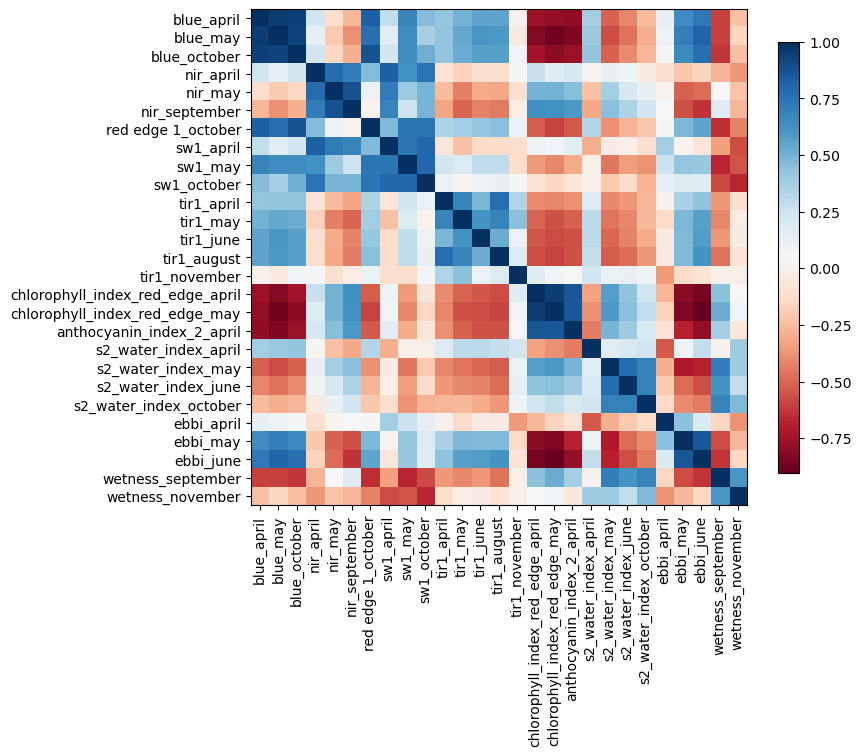

In [6]:
# correlation plot
corr = spearmanr(df_vars).correlation

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
pos = ax.imshow(corr,cmap='RdBu')
ax.set_xticks(np.arange(0,len(vars),1))
ax.set_yticks(np.arange(0,len(vars),1))
ax.set_xticklabels(df_vars.columns, rotation="vertical")
ax.set_yticklabels(df_vars.columns)
fig.colorbar(pos,shrink=0.7)
plt.show()

In [7]:


df_sample = df.sample(n=12000,replace=False)

X = df_sample.loc[:,mask]
y = df_sample['canopy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
X_train.shape

model = RandomForestRegressor(n_estimators=500,max_features='sqrt',max_samples=0.5).fit(X_train,y_train)

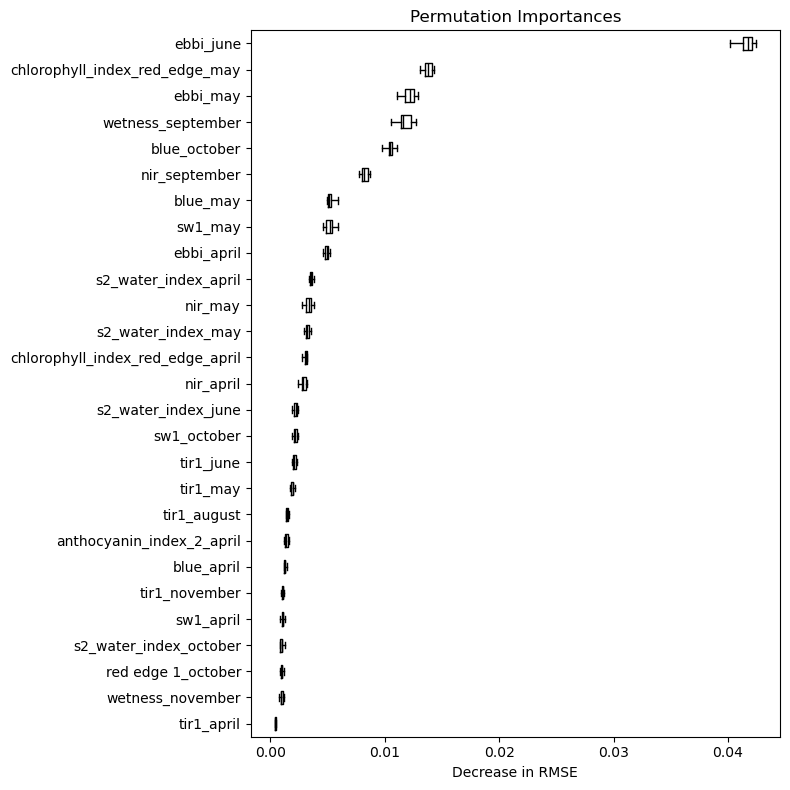

In [8]:
# variable importance


result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2,scoring='neg_root_mean_squared_error'
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_test.columns[sorted_importances_idx],
)

# plot results
box_color = dict(color='black')
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
# plot importances
plt.boxplot(importances,vert=False, whis=10,boxprops=box_color,whiskerprops=box_color,medianprops=box_color,capprops=box_color)
ax.set_title("Permutation Importances")
#ax.axvline(x=0,  linestyle="--")
ax.set_xlabel("Decrease in RMSE")
ax.set_yticklabels(importances.columns)
ax.figure.tight_layout()

In [ ]:
# different approaches to dividing up features

corr_df = rfp.feature_corr_matrix(df_vars)

# get all correlations > .8
corr_max = corr_df[(corr_df >= 0.8) | (corr_df <= -0.8)]
corr_max = corr_max[corr_max != 1]
corr_max

# groups of multiple correlated features
fts = []
for col in corr_max.columns:
    non_na_indices = corr_max[col].notna()
    ls = corr_max.index[non_na_indices].to_list()
    ls.append(col)
    fts.append(ls)

# pairs of correlated variables
features = [sorted(list(x)) for x in list(corr_max.stack().index)]
print(len(features))
# remove symmetric variable lists
features_nodupes = [list(x) for x in dict.fromkeys(map(tuple, features))]


# group by bands
mainlist = []
for e in ['nir','tir1','red edge','chlorophyll','ebbi','water','wetness','sw1','ireci','blue','carotenoid']:
    sublist = []
    for col in corr_max.columns:
        if e in col:
            sublist.append(col)
    mainlist.append(sublist)

mainlist

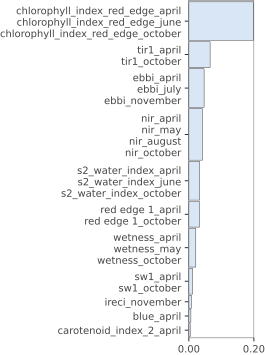

In [147]:
I = rfp.importances(model, X_test, y_test, features=mainlist)
rfp.plot_importances(I)